# Building Direction

`footprint_attributes.direction` computes a building's plan orientation from
its footprint polygon: the longer dimension `L1`/`dir1`, the shorter
dimension `L2`/`dir2`, and the compass `bearing` of the weak (shorter) axis.

Two independent methods are provided, `bbox` (minimum rotated bounding box)
and `inertia` (principal axes of the second moment of area). Both accept a
`mode` keyword to select what is returned, and an optional `direction=`
vector to force a specific axis instead of deriving it from the geometry.

This notebook first shows how the module behaves on idealized shapes with
a known-by-construction answer, then runs it on the three real pilot-area
datasets (San José, Guatemala City, Santo Domingo).

## Setup

In [1]:
import sys
sys.path.insert(0, "../tests")  # so `import shapes` finds tests/shapes.py

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from footprint_attributes import direction
from shapes import CRS, gdf_of, l_shape_polygon, rect_polygon, square_polygon


## Part 1 — Theory on idealized shapes

### A rectangle at known rotation angles

A 20 x 10 m rectangle rotated by a known angle has a known answer:
`L1=20`, `L2=10`, and `bearing = -angle` (clockwise-from-North convention).

In [2]:
angles = [-60, -40, -30, -10, 0, 10, 30, 40, 60]
rects = gpd.GeoDataFrame({"angle": angles}, geometry=[rect_polygon(a) for a in angles], crs=CRS)

L1, dir1, L2, dir2, bearing_bbox = direction.bbox(rects, mode="all")
L1i, dir1i, L2i, dir2i, bearing_inertia = direction.inertia(rects, mode="all")

report = rects[["angle"]].copy()
report["L1_bbox"], report["L2_bbox"], report["bearing_bbox"] = L1, L2, bearing_bbox
report["L1_inertia"], report["L2_inertia"], report["bearing_inertia"] = L1i, L2i, bearing_inertia
report["expected_bearing"] = -report["angle"]
report


,angle,L1_bbox,L2_bbox,bearing_bbox,L1_inertia,L2_inertia,bearing_inertia,expected_bearing
0,-60,20.058485,10.117489,59.662921,20.0,10.0,60.0,60
1,-40,20.077826,10.156574,40.449438,20.0,10.0,40.0,40
2,-30,20.058485,10.117489,30.337079,20.0,10.0,30.0,30
3,-10,20.019572,10.039202,10.112360,20.0,10.0,10.0,10
4,0,20.000000,10.000000,0.000000,20.0,10.0,0.0,0
5,10,20.019572,10.039202,-10.112360,20.0,10.0,-10.0,-10
6,30,20.058485,10.117489,-30.337079,20.0,10.0,-30.0,-30
7,40,20.077826,10.156574,-40.449438,20.0,10.0,-40.0,-40
8,60,20.058485,10.117489,-59.662921,20.0,10.0,-60.0,-60


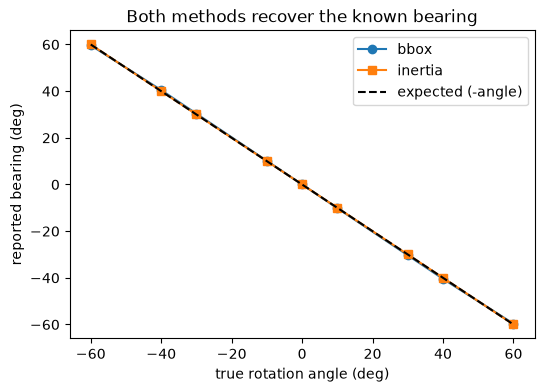

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(report["angle"], report["bearing_bbox"], "o-", label="bbox")
ax.plot(report["angle"], report["bearing_inertia"], "s-", label="inertia")
ax.plot(report["angle"], report["expected_bearing"], "k--", label="expected (-angle)")
ax.set_xlabel("true rotation angle (deg)")
ax.set_ylabel("reported bearing (deg)")
ax.legend()
ax.set_title("Both methods recover the known bearing")
plt.show()


### Degenerate case: a square

A square has no unique principal axis. Both methods must still run without
error and respect `L1 == L2`; the specific `dir1` returned is an
implementation artefact, not a meaningful "direction".

In [4]:
square = gdf_of(square_polygon())
print("bbox   :", direction.bbox(square, mode="dimensions"))
print("inertia:", direction.inertia(square, mode="dimensions"))


bbox   : ([np.float64(10.0)], [np.float64(10.0)])
inertia: ([np.float64(10.0)], [np.float64(10.0)])


### A non-rectangular footprint: L-shape

For a non-rectangular footprint, `L1`/`L2` are the circumscribed-rectangle
lengths along the chosen principal axes.

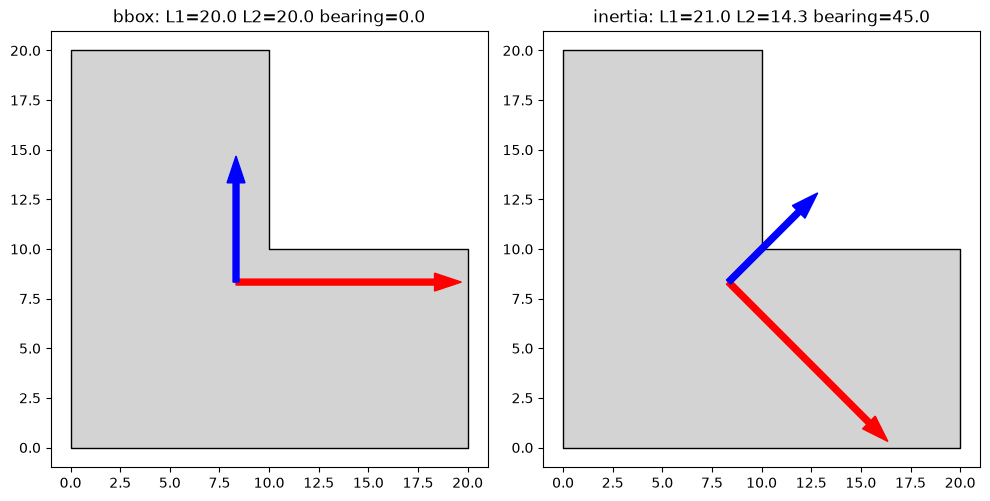

In [5]:
l_shape = gdf_of(l_shape_polygon())

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (name, fn) in zip(axes, {"bbox": direction.bbox, "inertia": direction.inertia}.items()):
    L1v, dir1v, L2v, dir2v, bearing_v = fn(l_shape, mode="all")
    l_shape.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
    c = l_shape.geometry.iloc[0].centroid
    ax.arrow(c.x, c.y, dir1v[0][0]*10, dir1v[0][1]*10, color="red", width=0.3, label="dir1")
    ax.arrow(c.x, c.y, dir2v[0][0]*5, dir2v[0][1]*5, color="blue", width=0.3, label="dir2")
    ax.set_title(f"{name}: L1={L1v[0]:.1f} L2={L2v[0]:.1f} bearing={bearing_v[0]:.1f}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()


### Forcing a specific axis

Both methods accept a `direction=` vector to force `dir1` (e.g. to align
with a street front or a party wall) instead of deriving it from the
geometry.

In [6]:
one = gdf_of(rect_polygon())
L1f, dir1f, L2f, dir2f, bearing_f = direction.bbox(one, mode="all", direction=np.array([1.0, 1.0]))
print("Forced 45 deg axis -> L1 =", L1f[0], " L2 =", L2f[0], " dir1 =", dir1f[0])


Forced 45 deg axis -> L1 = 21.213203435596423  L2 = 21.213203435596423  dir1 = [0.70710678 0.70710678]


### Worst-case eccentricity direction

`direction.eccentricity.EC8` / `.CSCR2010` return the analysis angle
(radians, from the principal axis) that maximises the eccentricity ratio
for a given seismic code — used internally by `shape.EC8` /
`shape.CSCR2010`. A symmetric rectangle has zero eccentricity (no optimum
needed); an asymmetric L-shape has a non-zero worst-case angle.

In [7]:
symmetric = gdf_of(rect_polygon())
asymmetric = l_shape

for name, gdf in [("symmetric rectangle", symmetric), ("asymmetric L-shape", asymmetric)]:
    x_opt = direction.eccentricity.EC8(gdf)
    print(f"{name:22s} -> x_opt = {x_opt[0]:.4f} rad")


symmetric rectangle    -> x_opt = 0.0000 rad
asymmetric L-shape     -> x_opt = 0.2527 rad


## Part 2 — Real data: the three pilot areas

Same computations, run on the actual digitised footprints from San José
(Costa Rica), Guatemala City, and Santo Domingo (Dominican Republic).

In [8]:
CITY_FILES = {
    "san_jose": "data/san_jose_pilot_region.gpkg",
    "guatemala": "data/guatemala_pilot_region.gpkg",
    "santo_domingo": "data/santo_domingo_pilot_region.gpkg",
}

def load_city(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].reset_index(drop=True)
    if (gdf.geometry.type == "MultiPolygon").any():
        gdf = gdf.explode(index_parts=False).reset_index(drop=True)
    gdf = gdf[gdf.geometry.type == "Polygon"].reset_index(drop=True)
    gdf.geometry = gdf.geometry.make_valid()
    gdf = gdf[gdf.geometry.type == "Polygon"].reset_index(drop=True)
    return gdf


In [9]:
results = {}
for city, path in CITY_FILES.items():
    gdf = load_city(path)
    gdf["bearing_inertia"] = direction.inertia(gdf)
    L1b, L2b = direction.bbox(gdf, mode="dimensions")
    gdf["L1_bbox"] = L1b
    gdf["L2_bbox"] = L2b
    gdf["bearing_bbox"] = direction.bbox(gdf)
    results[city] = gdf
    print(f"{city:15s} {len(gdf):5d} footprints")


san_jose          911 footprints


guatemala         435 footprints


santo_domingo    1463 footprints


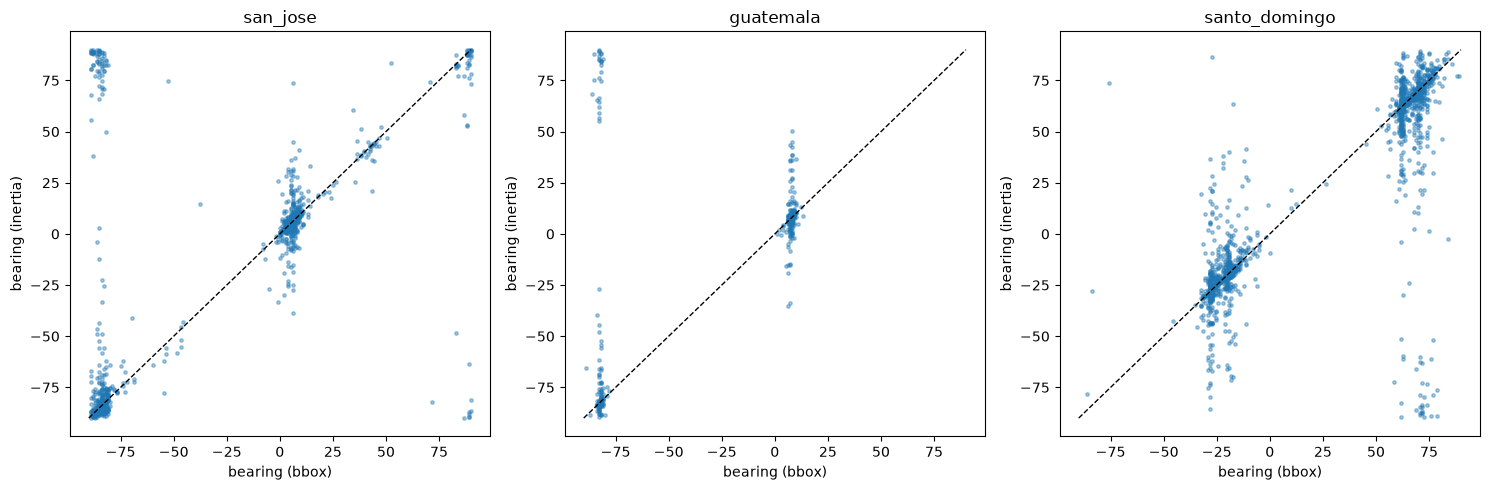

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (city, gdf) in zip(axes, results.items()):
    ax.scatter(gdf["bearing_bbox"], gdf["bearing_inertia"], s=6, alpha=0.4)
    ax.plot([-90, 90], [-90, 90], "k--", lw=1)
    ax.set_title(city)
    ax.set_xlabel("bearing (bbox)")
    ax.set_ylabel("bearing (inertia)")
plt.tight_layout()
plt.show()


## Result

One GeoDataFrame per city, each carrying the computed direction
attributes. Suggested columns to visualise on a map:

- `bearing_inertia` / `bearing_bbox` — building orientation (deg from North)
- `L1_bbox`, `L2_bbox` — plan dimensions (m)


In [11]:
san_jose_gdf = results["san_jose"]
guatemala_gdf = results["guatemala"]
santo_domingo_gdf = results["santo_domingo"]

map_columns = ["id", "bearing_inertia", "bearing_bbox", "L1_bbox", "L2_bbox", "geometry"]
san_jose_gdf


,id,city,height,n_storeys,year,code_quality,structural_system,simplified_structural_system,roof,geometry,bearing_inertia,L1_bbox,L2_bbox,bearing_bbox
0,1000009.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,metallic,"POLYGON ((-84.10396 9.92614, -84.10405 9.92608...",14.395737,13.870306,12.101991,-37.415730
1,1219.0,san_jose,6.0,2.0,1975,pre_code,M,M,metallic,"POLYGON ((-84.10431 9.92621, -84.10426 9.92621...",3.377607,22.624348,7.211505,3.033708
2,1000010.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,dark_shadow,"POLYGON ((-84.10395 9.92618, -84.10397 9.92614...",24.013840,13.532780,4.678581,25.280899
3,1221.0,san_jose,6.0,2.0,1985,low_code,M,M,bright_concrete,"POLYGON ((-84.10471 9.92629, -84.10472 9.92628...",-85.975534,19.621873,5.940149,-85.955056
4,1222.0,san_jose,6.0,2.0,1988,medium_code,M,M,metallic,"POLYGON ((-84.10494 9.92626, -84.10494 9.92613...",-79.978056,15.256333,9.327421,-88.988764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,1000029.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,metallic,"POLYGON ((-84.10486 9.93244, -84.10484 9.9325,...",13.505059,21.767402,7.094139,14.157303
907,1000030.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,dark_shadow,"POLYGON ((-84.10486 9.92836, -84.10487 9.9282,...",7.525610,35.096331,17.241336,7.078652
908,1000031.0,san_jose,NaN,NaN,1985,low_code,NaN,NaN,metallic,"POLYGON ((-84.10393 9.92754, -84.10393 9.92762...",1.696188,19.032748,11.888973,2.022472
909,1000032.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,dark_shadow,"POLYGON ((-84.10333 9.92703, -84.10335 9.92701...",42.993301,22.352464,3.693766,42.471910


In [12]:
guatemala_gdf


,id,city,height,n_storeys,year,code_quality,structural_system,simplified_structural_system,roof,geometry,bearing_inertia,L1_bbox,L2_bbox,bearing_bbox
0,7,guatemala,21.0,7.0,1985,pre_code,CR,CR,metallic,"POLYGON ((-90.51386 14.64293, -90.5139 14.6426...",-68.838462,36.791441,26.609313,-82.921348
1,8,guatemala,6.0,2.0,1985,pre_code,CR,CR,bright_concrete,"POLYGON ((-90.51477 14.64314, -90.51483 14.642...",-55.573098,40.661726,37.539257,-81.910112
2,9,guatemala,18.0,6.0,1985,pre_code,CR,CR,bright_concrete,"POLYGON ((-90.51513 14.64308, -90.51516 14.642...",-85.397112,33.753861,22.784936,-82.921348
3,10,guatemala,9.0,3.0,1985,pre_code,CR,CR,dark_shadow,"POLYGON ((-90.51533 14.64311, -90.51538 14.642...",-82.385597,33.946299,20.539929,-81.910112
4,53,guatemala,3.0,1.0,1985,pre_code,M,M,bright_concrete,"POLYGON ((-90.51437 14.64267, -90.51436 14.642...",6.454729,17.281690,7.399867,6.067416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,1000020,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((-90.51218 14.64711, -90.51218 14.647...",-65.487654,13.606980,7.991534,-88.988764
431,1000021,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((-90.51227 14.64726, -90.51214 14.647...",0.067101,14.514457,11.088897,1.011236
432,1000024,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((-90.51426 14.6473, -90.51425 14.6473...",-88.288026,18.212842,9.681661,-86.966292
433,1000001,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((-90.5143 14.64326, -90.51423 14.6432...",-82.158042,27.559919,14.053234,-81.910112


In [13]:
santo_domingo_gdf


,id,city,height,n_storeys,year,code_quality,structural_system,simplified_structural_system,roof,geometry,bearing_inertia,L1_bbox,L2_bbox,bearing_bbox
0,756,santo_domingo,6.0,2.0,1985,low_code,M,M,metallic,"POLYGON ((-69.93995 18.46551, -69.93987 18.465...",73.165398,17.736671,10.427929,63.707865
1,1448,santo_domingo,3.0,1.0,1985,low_code,M,M,metallic,"POLYGON ((-69.93997 18.46406, -69.94001 18.464...",-24.951159,16.845533,9.912854,-28.314607
2,783,santo_domingo,3.0,1.0,1985,low_code,M,M,metallic,"POLYGON ((-69.9402 18.4662, -69.9401 18.46625,...",-30.274196,12.803540,8.754279,-27.303371
3,506,santo_domingo,9.0,3.0,1985,low_code,M,M,metallic,"POLYGON ((-69.94122 18.46761, -69.9412 18.4675...",-24.848624,11.048662,6.829210,-26.292135
4,952,santo_domingo,27.0,9.0,1985,low_code,CR,CR,asphalt,"POLYGON ((-69.94762 18.46039, -69.9476 18.4603...",85.235243,29.461327,15.602622,70.786517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458,411,santo_domingo,NaN,NaN,1985,low_code,NaN,NaN,NaN,"POLYGON ((-69.94085 18.46697, -69.94073 18.467...",69.708047,35.048138,24.330678,62.696629
1459,410,santo_domingo,9.0,3.0,1985,low_code,M,M,NaN,"POLYGON ((-69.94084 18.46691, -69.9409 18.4668...",86.381355,12.117208,10.260292,62.696629
1460,409,santo_domingo,12.0,4.0,1989,low_code,M,M,NaN,"POLYGON ((-69.94062 18.46689, -69.94052 18.466...",-28.759324,44.439927,34.224406,-28.314607
1461,408,santo_domingo,15.0,5.0,1985,low_code,M,M,NaN,"POLYGON ((-69.94049 18.46625, -69.94053 18.466...",-29.320053,24.112753,12.465234,-28.314607


In [14]:
map_columns


['id', 'bearing_inertia', 'bearing_bbox', 'L1_bbox', 'L2_bbox', 'geometry']